# Eksperimen: Telco Customer Churn - EDA & Preprocessing
**Proyek Akhir Kelas: Membangun Sistem Machine Learning - Dicoding**

Dataset: `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
Target Kolom: `Churn` (Yes/No)

## 0. Install & Import Library

In [3]:
# Install library yang dibutuhkan (jika belum ada)
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print('Library berhasil diimpor.')

Library berhasil diimpor.


## 1. Data Loading

In [4]:

EXCEL_PATH = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(EXCEL_PATH)

print('Dataset berhasil dimuat.')
print(f'Shape: {df.shape} ({df.shape[0]} baris, {df.shape[1]} kolom)')
df.head()

Dataset berhasil dimuat.
Shape: (7043, 21) (7043 baris, 21 kolom)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA)

### 2.1 Informasi Umum Dataset

In [21]:
# Cek tipe data dan jumlah non-null per kolom
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [22]:
# Statistik deskriptif untuk kolom numerik
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### 2.2 Investigasi Kolom `TotalCharges` (Object → Numerik)

In [29]:
# ============================================================
# TEMUAN (SETELAH FIX pd.read_csv): TotalCharges sudah bertipe numerik (float64).
# Namun, masih ada nilai NaN (hasil konversi dari spasi kosong oleh pd.read_csv).
# Solusi: Identifikasi dan tangani NaN.
# ============================================================

print('Tipe data TotalCharges (sebelum):', df['TotalCharges'].dtype)

# Temukan baris yang berisi NaN (Not a Number)
mask_nan = df['TotalCharges'].isna()
print(f'Jumlah baris dengan NaN pada TotalCharges: {mask_nan.sum()}')
print('\nContoh baris bermasalah (mengandung NaN):')
df[mask_nan][['customerID', 'tenure', 'TotalCharges', 'Churn']].head()

Tipe data TotalCharges (sebelum): float64
Jumlah baris dengan NaN pada TotalCharges: 11

Contoh baris bermasalah (mengandung NaN):


,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,NaN,No
753,3115-CZMZD,0,NaN,No
936,5709-LVOEQ,0,NaN,No
1082,4367-NUYAO,0,NaN,No
1340,1371-DWPAZ,0,NaN,No


In [30]:
# Konversi spasi kosong → NaN → float
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Tipe data TotalCharges (sesudah):', df['TotalCharges'].dtype)
print(f'Jumlah NaN pada TotalCharges: {df["TotalCharges"].isna().sum()}')

Tipe data TotalCharges (sesudah): float64
Jumlah NaN pada TotalCharges: 11


### 2.3 Analisis Missing Value

In [31]:
# Hitung jumlah dan persentase missing value per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

print('=== KOLOM DENGAN MISSING VALUE ===')
print(missing_df)

=== KOLOM DENGAN MISSING VALUE ===
              Jumlah Missing  Persentase (%)
TotalCharges              11        0.156183


### 2.4 Sebaran Target Kolom `Churn`

=== DISTRIBUSI TARGET: Churn ===
       Jumlah  Persentase (%)
Churn                        
No       5174           73.46
Yes      1869           26.54


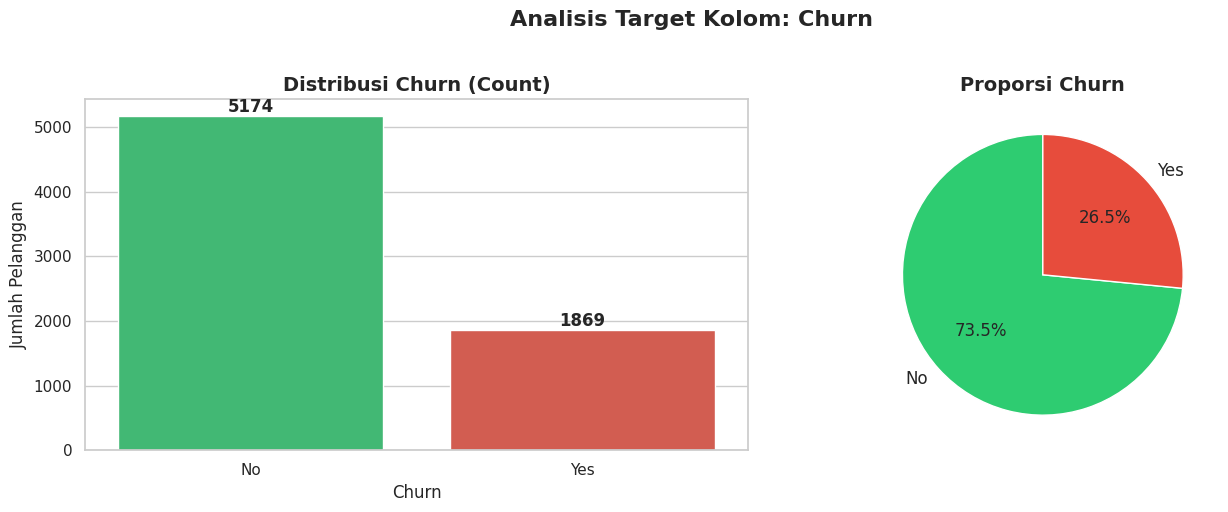


⚠️  Dataset TIDAK SEIMBANG (Imbalanced). Churn=No lebih dominan (73.5%).
Pertimbangkan teknik SMOTE/oversampling saat training model.


In [24]:
# Distribusi kelas target
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('=== DISTRIBUSI TARGET: Churn ===')
print(pd.DataFrame({'Jumlah': churn_counts, 'Persentase (%)': churn_pct.round(2)}))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.countplot(data=df, x='Churn', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Churn (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Churn', fontsize=14, fontweight='bold')

plt.suptitle('Analisis Target Kolom: Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n⚠️  Dataset TIDAK SEIMBANG (Imbalanced). Churn=No lebih dominan ({churn_pct["No"]:.1f}%).')
print('Pertimbangkan teknik SMOTE/oversampling saat training model.')

### 2.5 EDA Tambahan: Distribusi Fitur Numerik & Korelasi

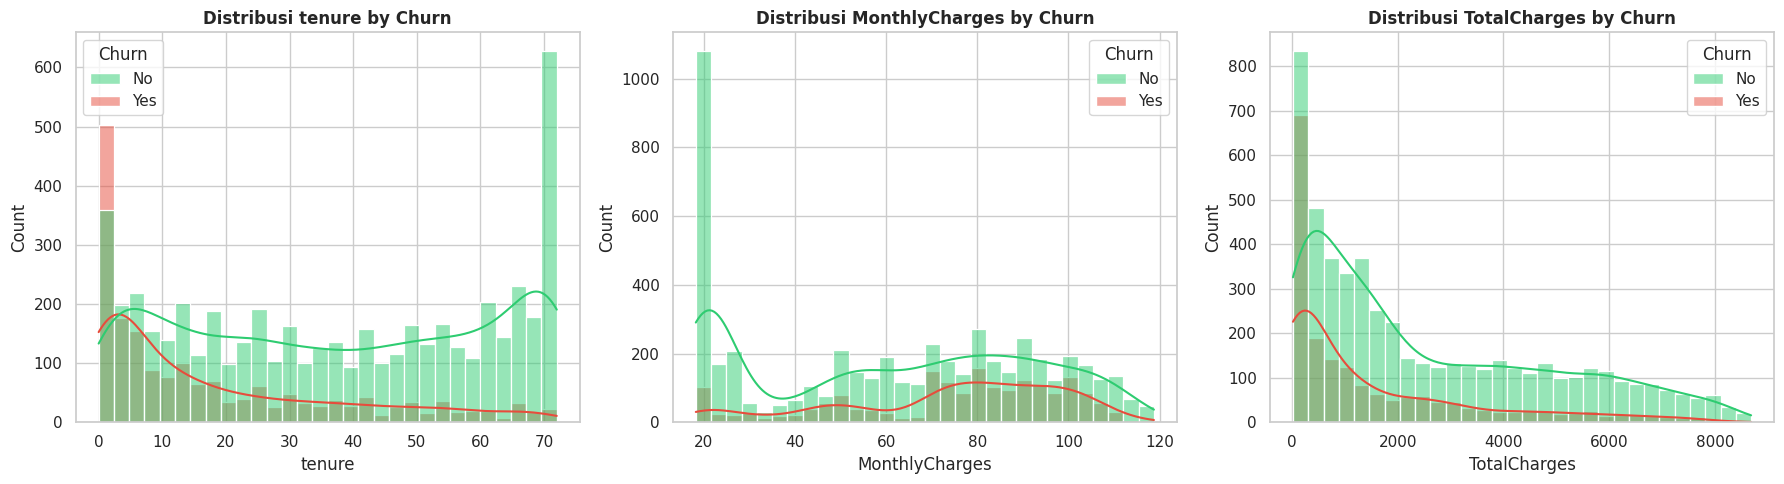

In [25]:
# Distribusi fitur numerik per kelas Churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette=['#2ecc71', '#e74c3c'], ax=axes[i], bins=30)
    axes[i].set_title(f'Distribusi {col} by Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

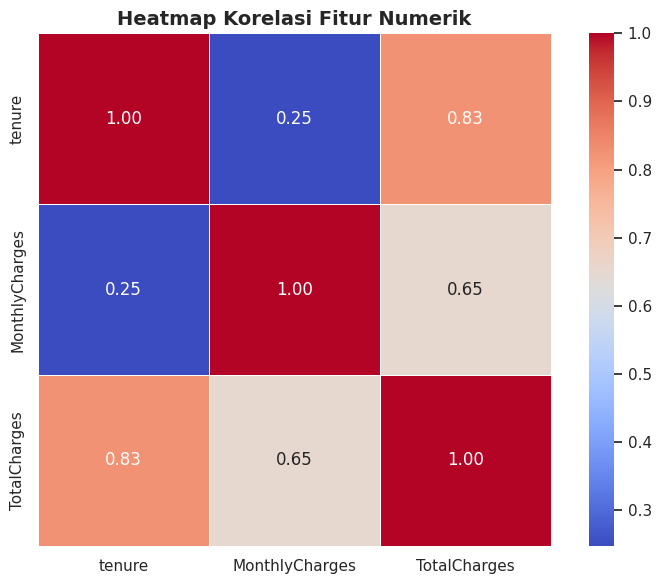

In [26]:
# Heatmap Korelasi (hanya kolom numerik)
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing Manual

### 3.1 Drop Kolom `customerID`

In [13]:
# customerID adalah identifier unik, tidak memiliki nilai prediktif
df_prep = df.copy()

df_prep.drop(columns=['customerID'], inplace=True)
print(f'Kolom setelah drop customerID: {df_prep.shape[1]} kolom')
print(df_prep.columns.tolist())

Kolom setelah drop customerID: 20 kolom
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 3.2 Handling Missing Value (Imputasi Median)

In [14]:
# Gunakan SimpleImputer dengan strategi 'median' untuk kolom numerik
# Median lebih robust terhadap outlier dibanding mean

num_features = df_prep.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f'Kolom numerik yang akan diimputasi: {num_features}')

imputer = SimpleImputer(strategy='median')
df_prep[num_features] = imputer.fit_transform(df_prep[num_features])

print(f'\nMissing value setelah imputasi: {df_prep.isnull().sum().sum()}')
print('✅ Imputasi median berhasil dilakukan.')

Kolom numerik yang akan diimputasi: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Missing value setelah imputasi: 0
✅ Imputasi median berhasil dilakukan.


### 3.3 Encoding Variabel Kategorikal

In [15]:
# ============================================================
# STRATEGI ENCODING:
# - Kolom BINER (2 nilai unik): LabelEncoder → lebih efisien
# - Kolom MULTI-KELAS (>2 nilai): OneHotEncoding via pd.get_dummies()
#   untuk menghindari ordinal bias
# ============================================================

cat_features = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal: {cat_features}')

binary_cols  = [col for col in cat_features if df_prep[col].nunique() == 2]
multi_cols   = [col for col in cat_features if df_prep[col].nunique() > 2]

print(f'\n→ Kolom biner (LabelEncoder)  : {binary_cols}')
print(f'→ Kolom multi-kelas (OHE)     : {multi_cols}')

Kolom kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

→ Kolom biner (LabelEncoder)  : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
→ Kolom multi-kelas (OHE)     : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [16]:
# LabelEncoder untuk kolom biner
le = LabelEncoder()
le_mapping = {}  # Simpan mapping untuk referensi

for col in binary_cols:
    df_prep[col] = le.fit_transform(df_prep[col])
    le_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('Label Encoding selesai. Mapping:')
for col, mapping in le_mapping.items():
    print(f'  {col}: {mapping}')

Label Encoding selesai. Mapping:
  gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
  Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
  PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
  PaperlessBilling: {'No': np.int64(0), 'Yes': np.int64(1)}
  Churn: {'No': np.int64(0), 'Yes': np.int64(1)}


In [17]:
# OneHotEncoding untuk kolom multi-kelas
# drop_first=True untuk menghindari multikolinearitas (dummy variable trap)
df_prep = pd.get_dummies(df_prep, columns=multi_cols, drop_first=True)

print(f'Shape setelah OHE: {df_prep.shape}')
print(f'Total fitur sekarang: {df_prep.shape[1]}')

Shape setelah OHE: (7043, 31)
Total fitur sekarang: 31


### 3.4 Scaling Fitur Numerik (StandardScaler)

In [18]:
# ============================================================
# CATATAN: Scaling hanya diterapkan pada fitur numerik ASLI,
# bukan pada kolom hasil OHE (sudah berskala 0/1) atau target.
# ============================================================

# Pisahkan fitur dan target
TARGET = 'Churn'
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

# Identifikasi kolom numerik asli (non-binary, non-OHE)
# Kolom hasil OHE memiliki nama dengan underscore dari get_dummies
num_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X[num_cols_to_scale] = scaler.fit_transform(X[num_cols_to_scale])

print(f'✅ Scaling selesai pada kolom: {num_cols_to_scale}')
print(f'\nStatistik setelah scaling:')
X[num_cols_to_scale].describe().round(4)

✅ Scaling selesai pada kolom: ['tenure', 'MonthlyCharges', 'TotalCharges']

Statistik setelah scaling:


,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7043.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-1.3182,-1.5459,-0.9991
25%,-0.9517,-0.9725,-0.8298
50%,-0.1373,0.1857,-0.3905
75%,0.9215,0.8338,0.6643
max,1.6137,1.7944,2.8267


## 4. Ringkasan Hasil Preprocessing

In [19]:
print('=' * 55)
print('       RINGKASAN HASIL PREPROCESSING')
print('=' * 55)
print(f'  Shape awal dataset       : {df.shape}')
print(f'  Shape X (fitur)          : {X.shape}')
print(f'  Shape y (target)         : {y.shape}')
print(f'  Missing value tersisa    : {X.isnull().sum().sum()}')
print(f'  Tipe data unik di X      : {X.dtypes.value_counts().to_dict()}')
print('=' * 55)

print('\nSampel X (5 baris pertama):')
display(X.head())

print('\nDistribusi y:')
print(y.value_counts())

       RINGKASAN HASIL PREPROCESSING
  Shape awal dataset       : (7043, 21)
  Shape X (fitur)          : (7043, 30)
  Shape y (target)         : (7043,)
  Missing value tersisa    : 0
  Tipe data unik di X      : {dtype('bool'): 21, dtype('int64'): 5, dtype('float64'): 4}

Sampel X (5 baris pertama):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0.0,1,0,-1.277445,0,1,-1.160323,-0.994242,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0.0,0,0,0.066327,1,0,-0.259629,-0.173244,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0.0,0,0,-1.236724,1,1,-0.362660,-0.959674,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0.0,0,0,0.514251,0,0,-0.746535,-0.194766,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0.0,0,0,-1.236724,1,1,0.197365,-0.940470,False,...,False,False,False,False,False,False,False,False,True,False



Distribusi y:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [20]:
# Simpan hasil preprocessing ke CSV (opsional, untuk validasi)
import os
os.makedirs('telco_preprocessing', exist_ok=True)

X.to_csv('telco_preprocessing/X_processed.csv', index=False)
y.to_csv('telco_preprocessing/y_processed.csv', index=False)

print('✅ Hasil preprocessing disimpan ke folder telco_preprocessing/')

✅ Hasil preprocessing disimpan ke folder telco_preprocessing/
